In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

   Unnamed: 0  Student_id  Age      Grade Employed  marks
0           0           1   19  1st Class      yes     29
1           1           2   20  2nd Class       no     41
2           2           3   18  1st Class       no     57
3           3           4   21  2nd Class       no     29
4           4           5   19  1st Class       no     57


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data-2.csv')
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())

df['Дата'] = pd.to_datetime(df['Дата'])

Index(['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество'], dtype='object')
         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data-2.csv')
df['Дата'] = pd.to_datetime(df['Дата'])
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()
grouped_df = grouped_df.rename(columns={'Количество': 'sales_sum'})

print(grouped_df.head())

        Дата  sales_sum
0 2018-01-04       3734
1 2018-01-05       3643
2 2018-01-06       3193
3 2018-01-07       3298
4 2018-01-09       4055


Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  sales_sum
0 2018-01-04       3734
1 2018-01-05       3643
2 2018-01-06       3193
3 2018-01-07       3298
4 2018-01-09       4055


Нарисуйте график продаж у `grouped_df`

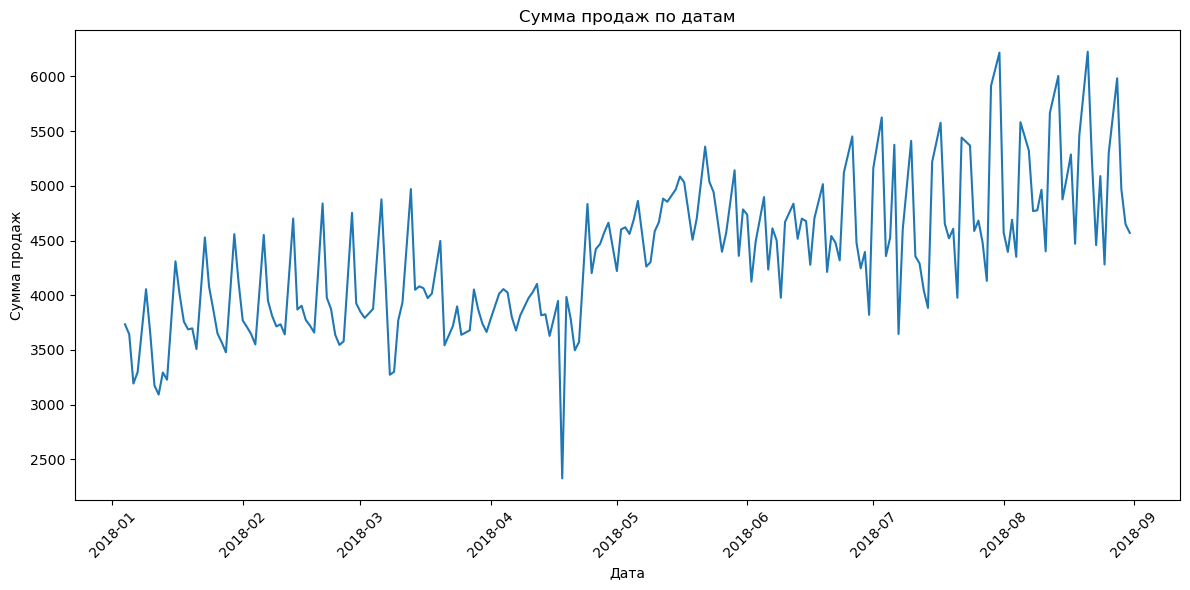

In [8]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['sales_sum'])
plt.title('Сумма продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [9]:
#На графике видно, что сумма продаж меняется неравномерно.
#Есть дни с более высокими значениями и периоды снижения. 
#Также заметны отдельные пики, то есть продажи в разные даты распределены 
#нестабильно

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
max_row = grouped_df.loc[grouped_df['sales_sum'].idxmax()]
print(max_row)

Дата         2018-08-21 00:00:00
sales_sum                   6226
Name: 195, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
df['weekday'] = df['Дата'].dt.day_name()

filtered = df[
    (df['weekday'] == 'Wednesday') &
    (df['Дата'].dt.month.isin([6, 7, 8]))
]

top_products = (
    filtered.groupby(['Склад', 'Номенклатура'], as_index=False)['Количество']
    .sum()
    .sort_values(['Склад', 'Количество'], ascending=[True, False])
)

top_products = top_products.groupby('Склад').head(1)
print(top_products)

    Склад Номенклатура  Количество
1       1    product_1        2981
24      2    product_1        2887
46      3    product_1        2267
69      4    product_1        2385
92      5    product_1        1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('data-2.csv')
df['Дата'] = pd.to_datetime(df['Дата'])

grouped_df = (
    df.groupby('Дата', as_index=False)['Количество']
      .sum()
      .rename(columns={'Количество': 'sales_sum'})
)

print(grouped_df.head())


        Дата  sales_sum
0 2018-01-04       3734
1 2018-01-05       3643
2 2018-01-06       3193
3 2018-01-07       3298
4 2018-01-09       4055


In [14]:
weather = pd.read_csv(
    'utf8.csv',
    sep=';',
    comment='#',
    encoding='utf-8',
    index_col=False
)

weather.columns = weather.columns.str.strip()

weather = weather[['Местное время в Астане', 'T']].copy()

weather['Местное время в Астане'] = pd.to_datetime(
    weather['Местное время в Астане'],
    format='%d.%m.%Y %H:%M',
    errors='coerce'
)

weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

weather = weather.dropna(subset=['Местное время в Астане', 'T'])

weather['Дата'] = weather['Местное время в Астане'].dt.normalize()

weather_daily = weather.groupby('Дата', as_index=False)['T'].mean()

print(weather_daily.head())


        Дата        T
0 2018-01-04 -14.0750
1 2018-01-05 -16.8625
2 2018-01-06 -13.3000
3 2018-01-07 -12.7500
4 2018-01-08 -15.4125


In [19]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата']).dt.normalize()

merged = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')

print("Размер merged:", merged.shape)
print(merged.head())

Размер merged: (205, 3)
        Дата  sales_sum        T
0 2018-01-04       3734 -14.0750
1 2018-01-05       3643 -16.8625
2 2018-01-06       3193 -13.3000
3 2018-01-07       3298 -12.7500
4 2018-01-09       4055  -6.2500


In [23]:
print(merged.shape)

(205, 3)


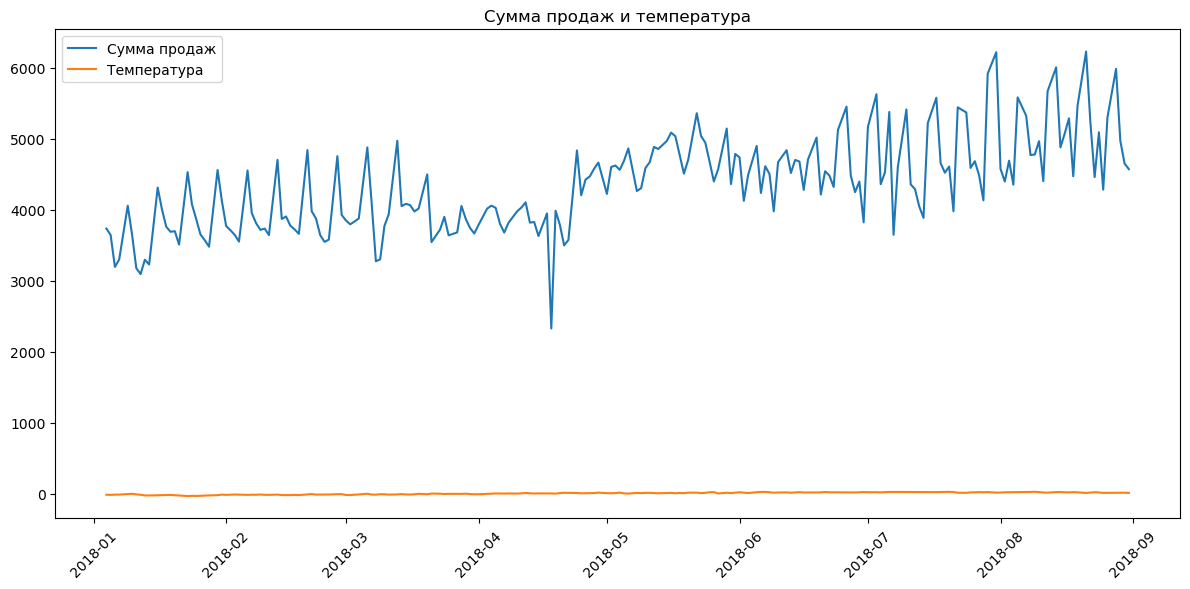

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(merged['Дата'], merged['sales_sum'], label='Сумма продаж')
plt.plot(merged['Дата'], merged['T'], label='Температура')
plt.legend()
plt.xticks(rotation=45)
plt.title('Сумма продаж и температура')
plt.tight_layout()
plt.show()


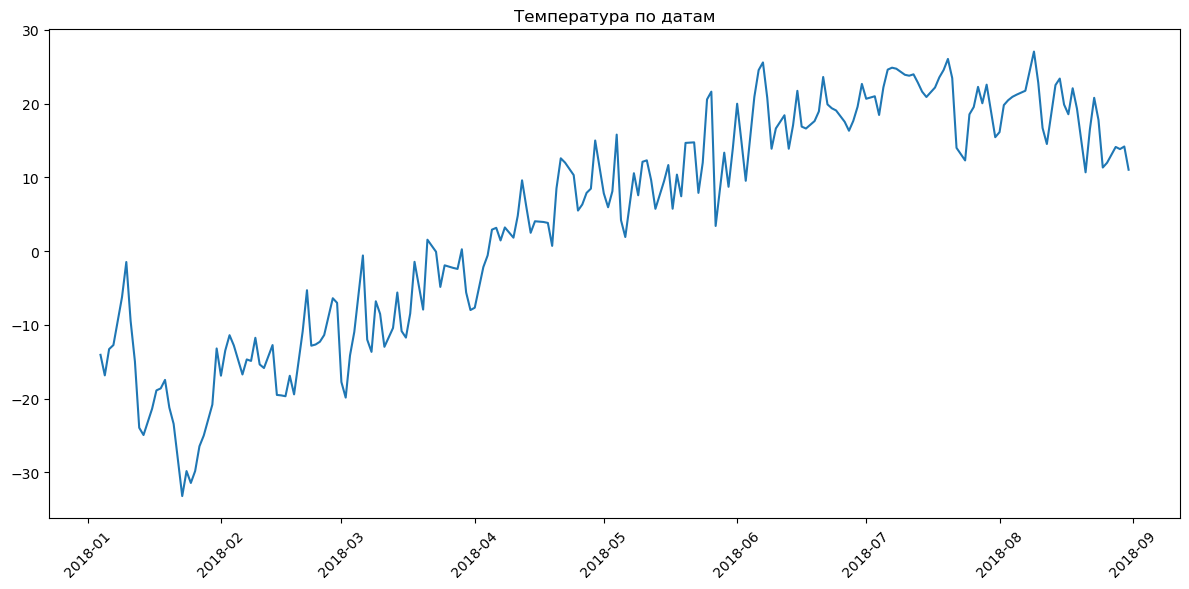

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(merged['Дата'], merged['T'])
plt.xticks(rotation=45)
plt.title('Температура по датам')
plt.tight_layout()
plt.show()


In [22]:
print(merged[['sales_sum', 'T']].corr())

           sales_sum         T
sales_sum   1.000000  0.600219
T           0.600219  1.000000


#После объединения данных по одинаковым датам видно, что температура и сумма продаж меняются неравномерно. Явной сильной зависимости между температурой и продажами не наблюдается, связь слабая.